In [4]:
from google.colab import files
uploaded = files.upload()

Saving movies_enriched_5k.csv to movies_enriched_5k.csv


In [5]:
# ============================================================
# SETUP: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import binom, norm
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'Arial'
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('movies_enriched_5k.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(df.columns.tolist())


Dataset loaded: 5000 rows, 21 columns
['IMDb_ID', 'Title', 'originalTitle', 'isAdult', 'Year', 'Duration', 'Genres', 'Rating', 'Votes', 'Director', 'Writer', 'Actors', 'Plot', 'Budget', 'Revenue', 'Popularity', 'Tagline', 'TMDb_ID', 'Country', 'Languages', 'Poster_URL']


In [6]:
# ============================================================
# SECTION 1: Data Preprocessing
# ============================================================

# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')


Missing values per column:
IMDb_ID            0
Title              0
originalTitle      0
isAdult            0
Year               0
Duration           1
Genres             0
Rating             0
Votes              0
Director           0
Writer            29
Actors            67
Plot               7
Budget             0
Revenue            0
Popularity         0
Tagline          539
TMDb_ID            5
Country            0
Languages          2
Poster_URL        10
dtype: int64

Duplicate rows: 0


In [7]:
# Remove rows with missing Duration
df_clean = df.dropna(subset=['Duration']).copy()
print(f'After removing missing Duration: {len(df_clean)} rows')

# Create binary outcome variable: HighRated = 1 if Rating >= 7.0
df_clean['HighRated'] = (df_clean['Rating'] >= 7.0).astype(int)
print(f'High-Rated movies (>=7.0): {df_clean["HighRated"].sum()} ({df_clean["HighRated"].mean()*100:.2f}%)')

# Treat Budget=0 and Revenue=0 as missing (undisclosed)
df_clean['Budget_valid'] = df_clean['Budget'].replace(0, np.nan)
df_clean['Revenue_valid'] = df_clean['Revenue'].replace(0, np.nan)

print(f'\nFinal clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns')


After removing missing Duration: 4999 rows
High-Rated movies (>=7.0): 1826 (36.53%)

Final clean dataset: 4999 rows, 24 columns


In [8]:
# ============================================================
# SECTION 2: Descriptive Statistics
# ============================================================

focal_vars = ['Rating', 'Duration', 'Votes']

for col in focal_vars:
    print(f'\n--- {col} ---')
    print(f'Count:   {df_clean[col].count()}')
    print(f'Mean:    {df_clean[col].mean():.4f}')
    print(f'Median:  {df_clean[col].median():.4f}')
    print(f'Std Dev: {df_clean[col].std():.4f}')
    print(f'Min:     {df_clean[col].min():.4f}')
    print(f'Q1:      {df_clean[col].quantile(0.25):.4f}')
    print(f'Q3:      {df_clean[col].quantile(0.75):.4f}')
    print(f'Max:     {df_clean[col].max():.4f}')
    print(f'IQR:     {df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25):.4f}')
    print(f'Skewness:{df_clean[col].skew():.4f}')
    print(f'Kurtosis:{df_clean[col].kurt():.4f}')



--- Rating ---
Count:   4999
Mean:    6.5617
Median:  6.6000
Std Dev: 0.9729
Min:     1.0000
Q1:      6.0000
Q3:      7.2000
Max:     9.0000
IQR:     1.2000
Skewness:-0.9778
Kurtosis:2.8495

--- Duration ---
Count:   4999
Mean:    112.0650
Median:  108.0000
Std Dev: 21.1013
Min:     46.0000
Q1:      97.0000
Q3:      122.0000
Max:     374.0000
IQR:     25.0000
Skewness:1.6530
Kurtosis:8.2048

--- Votes ---
Count:   4999
Mean:    143591.9298
Median:  70280.0000
Std Dev: 203248.1300
Min:     23766.0000
Q1:      39478.5000
Q3:      156548.0000
Max:     3026849.0000
IQR:     117069.5000
Skewness:4.4170
Kurtosis:31.4746


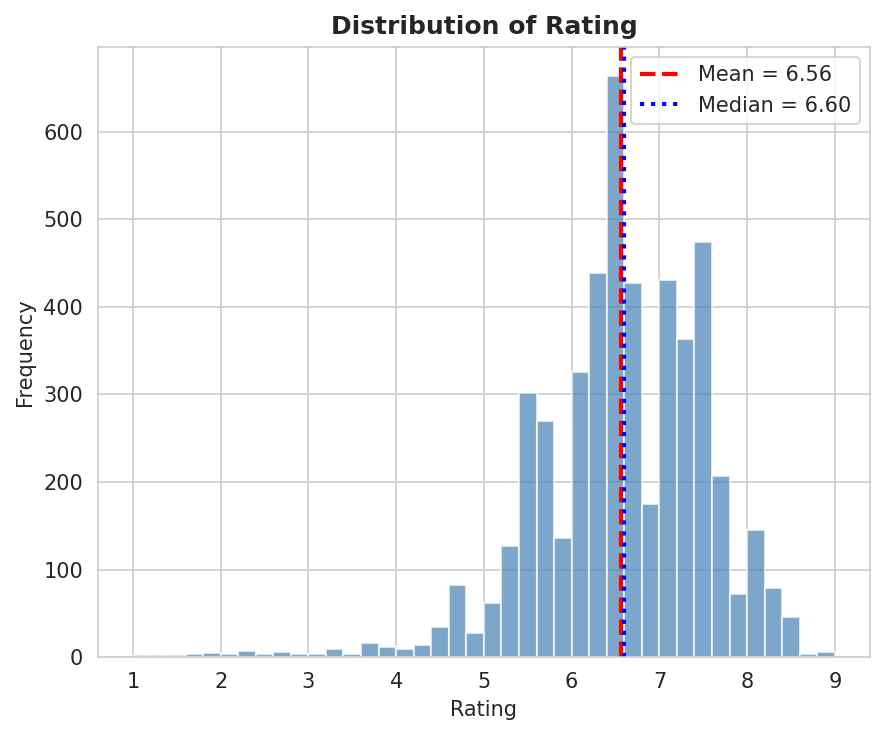

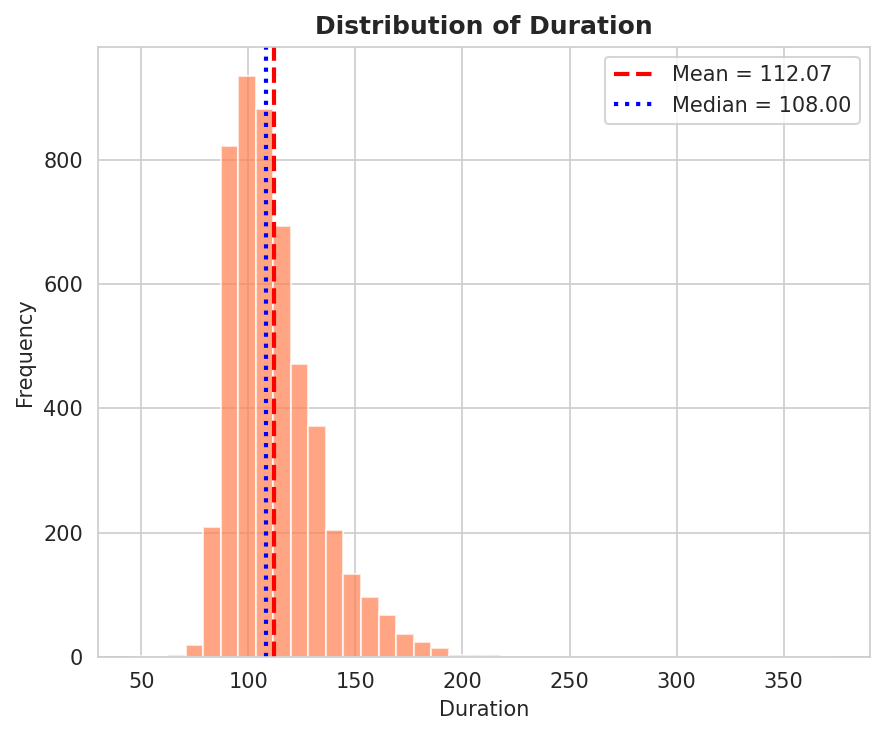

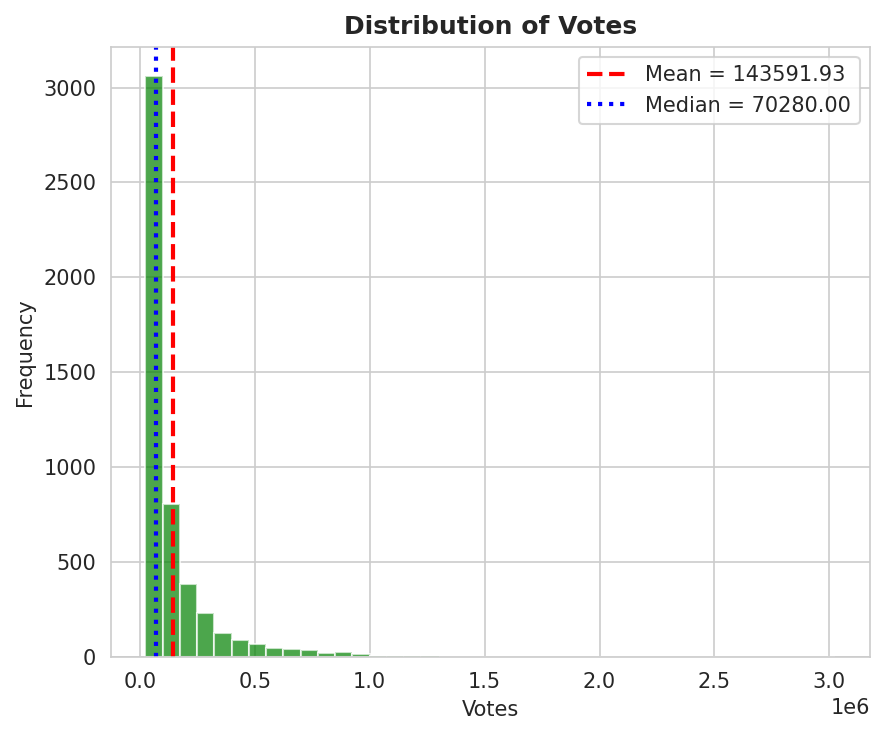

In [9]:
# ============================================================
# SECTION 3A: Separate Histograms with Mean/Median Lines
# ============================================================

colors = {
    'Rating': 'steelblue',
    'Duration': 'coral',
    'Votes': 'green'
}

for col in ['Rating', 'Duration', 'Votes']:
    plt.figure(figsize=(6, 5))

    plt.hist(
        df_clean[col],
        bins=40,
        color=colors[col],
        alpha=0.7,
        edgecolor='white'
    )

    plt.axvline(
        df_clean[col].mean(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {df_clean[col].mean():.2f}'
    )

    plt.axvline(
        df_clean[col].median(),
        color='blue',
        linestyle=':',
        linewidth=2,
        label=f'Median = {df_clean[col].median():.2f}'
    )

    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{col.lower()}_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()

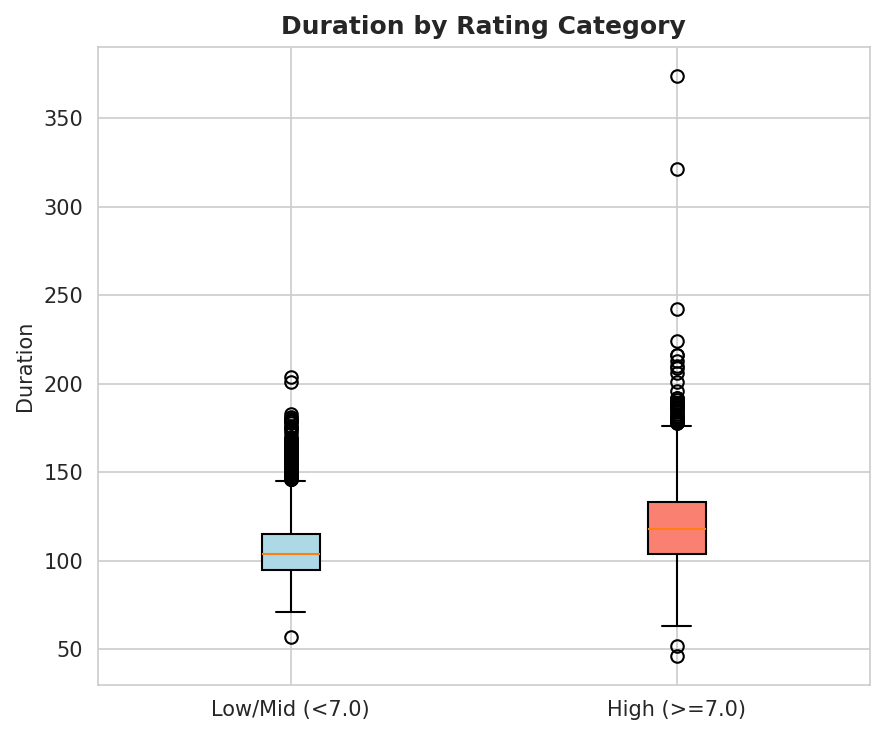

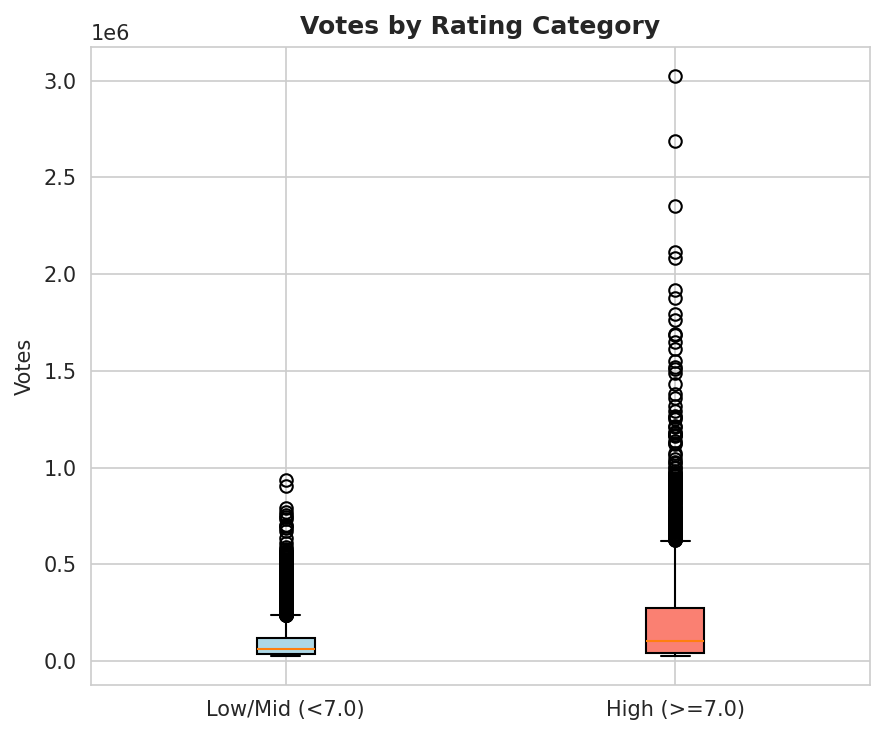

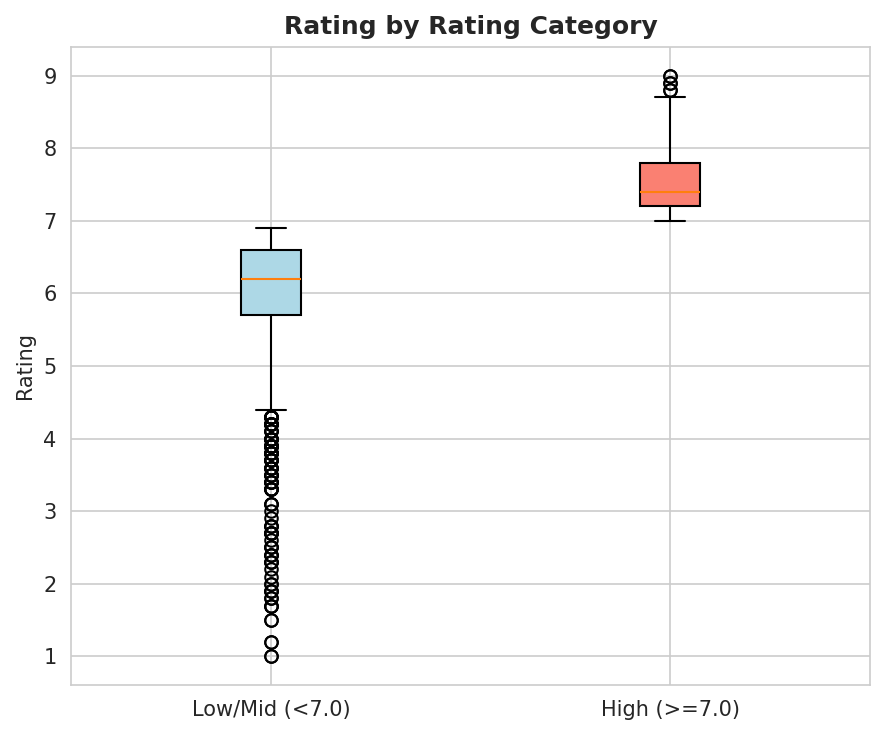

In [10]:
# ============================================================
# SECTION 3B: Separate Boxplots by Rating Category
# ============================================================

for col in ['Duration', 'Votes', 'Rating']:

    plt.figure(figsize=(6, 5))

    groups = [
        df_clean[df_clean['HighRated'] == 0][col],
        df_clean[df_clean['HighRated'] == 1][col]
    ]

    bp = plt.boxplot(
        groups,
        patch_artist=True,
        labels=['Low/Mid (<7.0)', 'High (>=7.0)']
    )

    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('salmon')

    plt.title(f'{col} by Rating Category', fontweight='bold')
    plt.ylabel(col)

    plt.tight_layout()
    plt.savefig(f'{col.lower()}_boxplot.png',
                dpi=150,
                bbox_inches='tight')
    plt.show()

In [11]:
# ============================================================
# SECTION 3C: Genre Analysis
# ============================================================
from collections import Counter

all_genres = []
for g in df_clean['Genres'].dropna():
    all_genres.extend([x.strip() for x in g.split(',')])

genre_counts = Counter(all_genres)
top_genres = dict(sorted(genre_counts.items(), key=lambda x: -x[1])[:10])
print('Top 10 genres by count:')
for k, v in top_genres.items(): print(f'  {k}: {v}')

# Average rating per genre
genre_ratings = {}
for g in top_genres:
    mask = df_clean['Genres'].str.contains(g, na=False)
    genre_ratings[g] = df_clean.loc[mask, 'Rating'].mean()
print('\nAverage rating by genre:')
for k, v in sorted(genre_ratings.items(), key=lambda x: -x[1]): print(f'  {k}: {v:.4f}')


Top 10 genres by count:
  Drama: 2689
  Comedy: 1743
  Action: 1468
  Adventure: 1021
  Crime: 1019
  Thriller: 903
  Romance: 748
  Horror: 664
  Mystery: 642
  Biography: 421

Average rating by genre:
  Biography: 7.1515
  Drama: 6.8417
  Crime: 6.6570
  Romance: 6.5386
  Adventure: 6.4797
  Thriller: 6.4301
  Mystery: 6.4089
  Action: 6.3987
  Comedy: 6.3900
  Horror: 6.0123


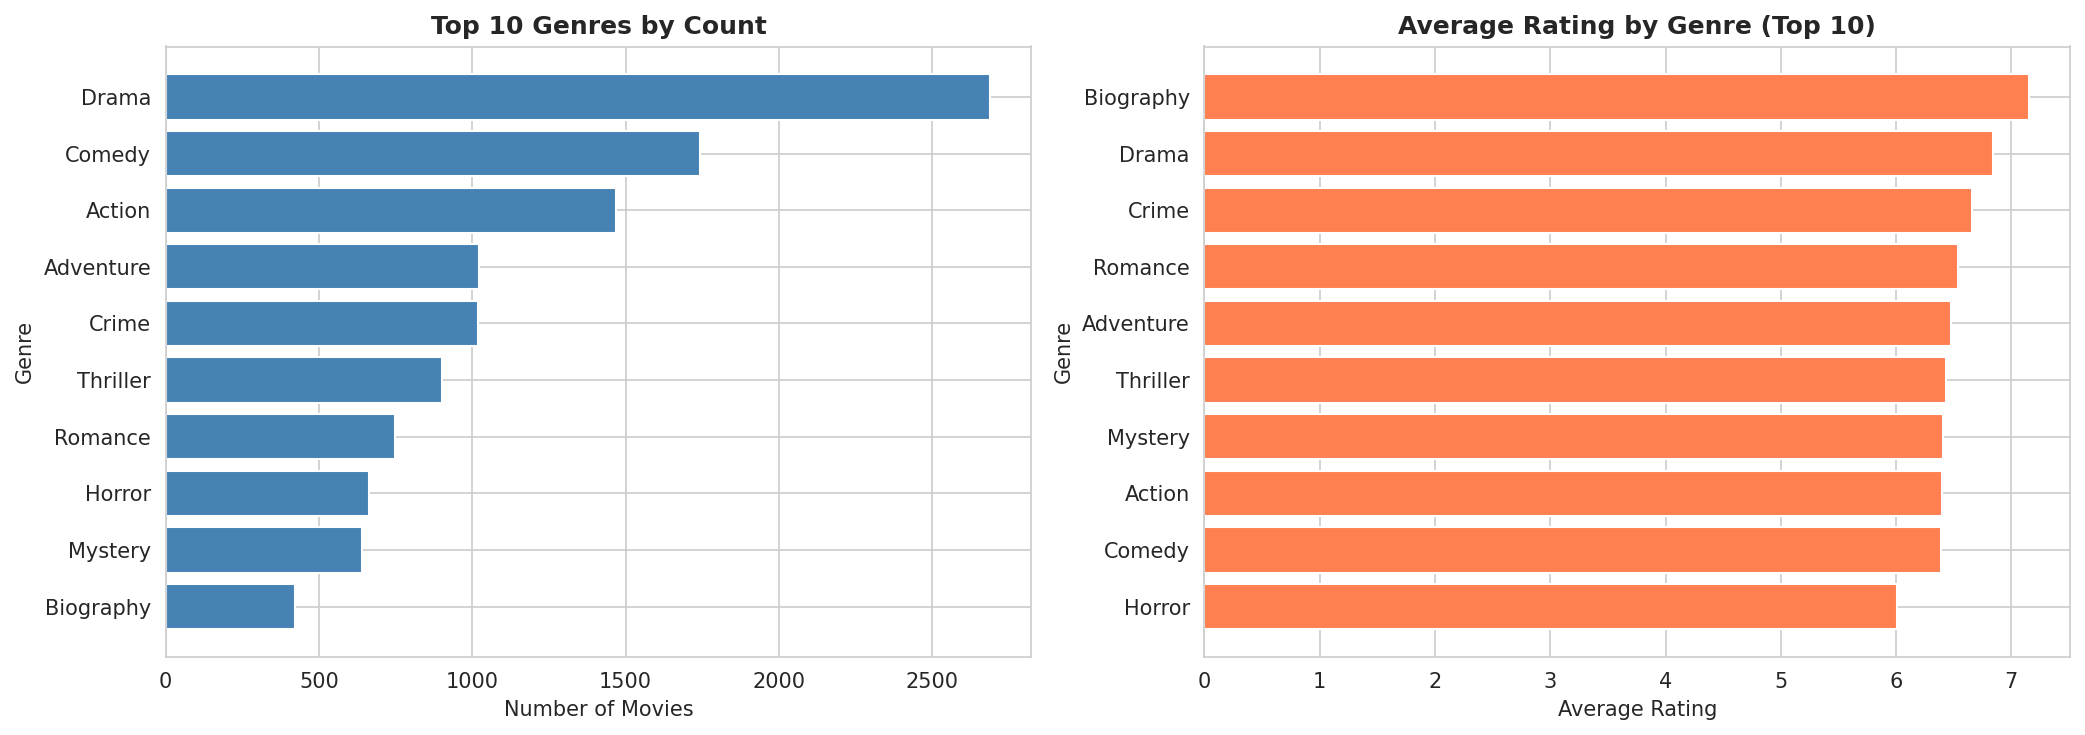

In [12]:
# ============================================================
# SECTION 3C: Genre Analysis Visualization
# ============================================================

import matplotlib.pyplot as plt

# Sort ratings for better visualization
sorted_ratings = sorted(
    genre_ratings.items(),
    key=lambda x: x[1],
    reverse=True
)

genres_rating = [x[0] for x in sorted_ratings]
ratings = [x[1] for x in sorted_ratings]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Left Plot: Top 10 Genres by Count
# ------------------------------------------------------------
axes[0].barh(
    list(top_genres.keys())[::-1],
    list(top_genres.values())[::-1],
    color='steelblue'
)

axes[0].set_title('Top 10 Genres by Count', fontweight='bold')
axes[0].set_xlabel('Number of Movies')
axes[0].set_ylabel('Genre')

# ------------------------------------------------------------
# Right Plot: Average Rating by Genre
# ------------------------------------------------------------
axes[1].barh(
    genres_rating[::-1],
    ratings[::-1],
    color='coral'
)

axes[1].set_title('Average Rating by Genre (Top 10)', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.savefig('fig3_genre_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# SECTION 4A: Empirical Probability & Conditional Probability
# ============================================================

# Prior probability
p_high = df_clean['HighRated'].mean()

# Conditional probabilities
med_votes = df_clean['Votes'].median()

low_group = df_clean[df_clean['Votes'] <= med_votes]
high_group = df_clean[df_clean['Votes'] > med_votes]

p_hr_low_eng = low_group['HighRated'].mean()
p_hr_high_eng = high_group['HighRated'].mean()

# Create summary table
prob_table = pd.DataFrame({
    'Audience Segment': [
        'Votes ≤ Median (Low Engagement)',
        'Votes > Median (High Engagement)',
        'Overall'
    ],
    'Count': [
        len(low_group),
        len(high_group),
        len(df_clean)
    ],
    'High-Rated Count': [
        low_group['HighRated'].sum(),
        high_group['HighRated'].sum(),
        df_clean['HighRated'].sum()
    ],
    'P(HighRated | Segment)': [
        p_hr_low_eng,
        p_hr_high_eng,
        p_high
    ]
})

prob_table['Rate'] = (
    prob_table['P(HighRated | Segment)'] * 100
).round(2).astype(str) + '%'

print(prob_table)

                   Audience Segment  Count  High-Rated Count  \
0   Votes ≤ Median (Low Engagement)   2500               732   
1  Votes > Median (High Engagement)   2499              1094   
2                           Overall   4999              1826   

   P(HighRated | Segment)    Rate  
0                0.292800  29.28%  
1                0.437775  43.78%  
2                0.365273  36.53%  


In [14]:
# ============================================================
# SECTION 4B: Bayes' Theorem
# ============================================================

# P(HighRated | Votes>Median) using Bayes
p_votes_gt_med = (df_clean['Votes'] > med_votes).mean()   # P(Votes>Median)
p_hr = df_clean['HighRated'].mean()                        # P(HighRated)
p_votes_gt_given_hr = df_clean.loc[df_clean['HighRated']==1,
                          'Votes'].apply(lambda x: x>med_votes).mean()

# Bayes: P(HighRated|Votes>Med) = P(Votes>Med|HighRated)*P(HighRated)/P(Votes>Med)
bayes_result = p_votes_gt_given_hr * p_hr / p_votes_gt_med
print(f'P(Votes>Median)          = {p_votes_gt_med:.4f}')
print(f'P(Votes>Med|HighRated)   = {p_votes_gt_given_hr:.4f}')
print(f'P(HighRated|Votes>Med)   = {bayes_result:.4f} (Bayes result)')


P(Votes>Median)          = 0.4999
P(Votes>Med|HighRated)   = 0.5991
P(HighRated|Votes>Med)   = 0.4378 (Bayes result)


p = 0.3653, n = 20
E[X] = np = 7.3055
Var[X] = np(1-p) = 4.6370
Std[X] = 2.1534

Selected P(X=k):
  P(X= 0) = 0.000113
  P(X= 1) = 0.001297
  P(X= 2) = 0.007088
  P(X= 3) = 0.024476
  P(X= 4) = 0.059863
  P(X= 5) = 0.110239
  P(X= 6) = 0.158601
  P(X= 7) = 0.182544
  P(X= 8) = 0.170707
  P(X= 9) = 0.130985
  P(X=10) = 0.082917


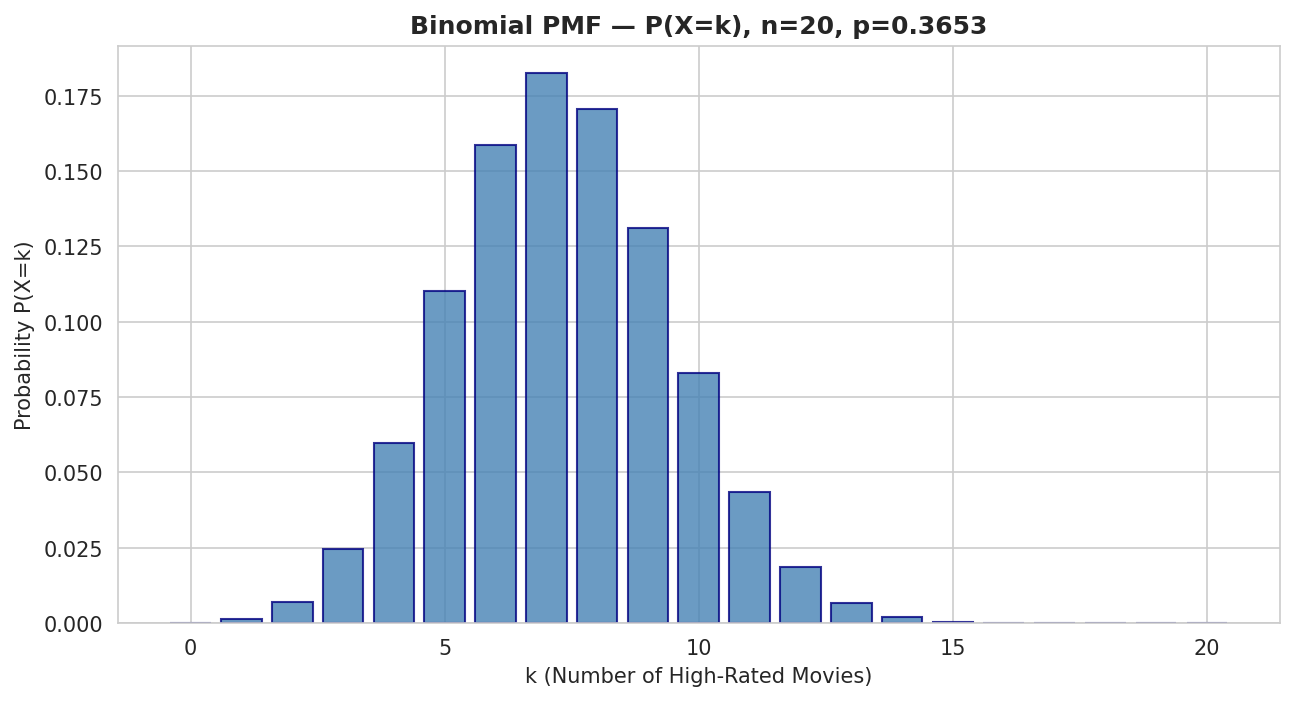

In [15]:
# ============================================================
# SECTION 4C: Binomial Distribution
# ============================================================

p = df_clean['HighRated'].mean()  # p = 0.3653
n = 20

# Expected value and variance
E_X = n * p
Var_X = n * p * (1 - p)
Std_X = np.sqrt(Var_X)
print(f'p = {p:.4f}, n = {n}')
print(f'E[X] = np = {E_X:.4f}')
print(f'Var[X] = np(1-p) = {Var_X:.4f}')
print(f'Std[X] = {Std_X:.4f}')

# PMF values
k_vals = np.arange(0, 21)
pmf_vals = binom.pmf(k_vals, n, p)
print('\nSelected P(X=k):')
for k, pv in zip(k_vals[:11], pmf_vals[:11]):
    print(f'  P(X={k:2d}) = {pv:.6f}')

# Plot
plt.figure(figsize=(10, 5))
plt.bar(k_vals, pmf_vals, color='steelblue', alpha=0.8, edgecolor='navy')
plt.title(f'Binomial PMF — P(X=k), n=20, p={p:.4f}', fontweight='bold')
plt.xlabel('k (Number of High-Rated Movies)'); plt.ylabel('Probability P(X=k)')
plt.savefig('fig4_binomial.png', dpi=150, bbox_inches='tight'); plt.show()


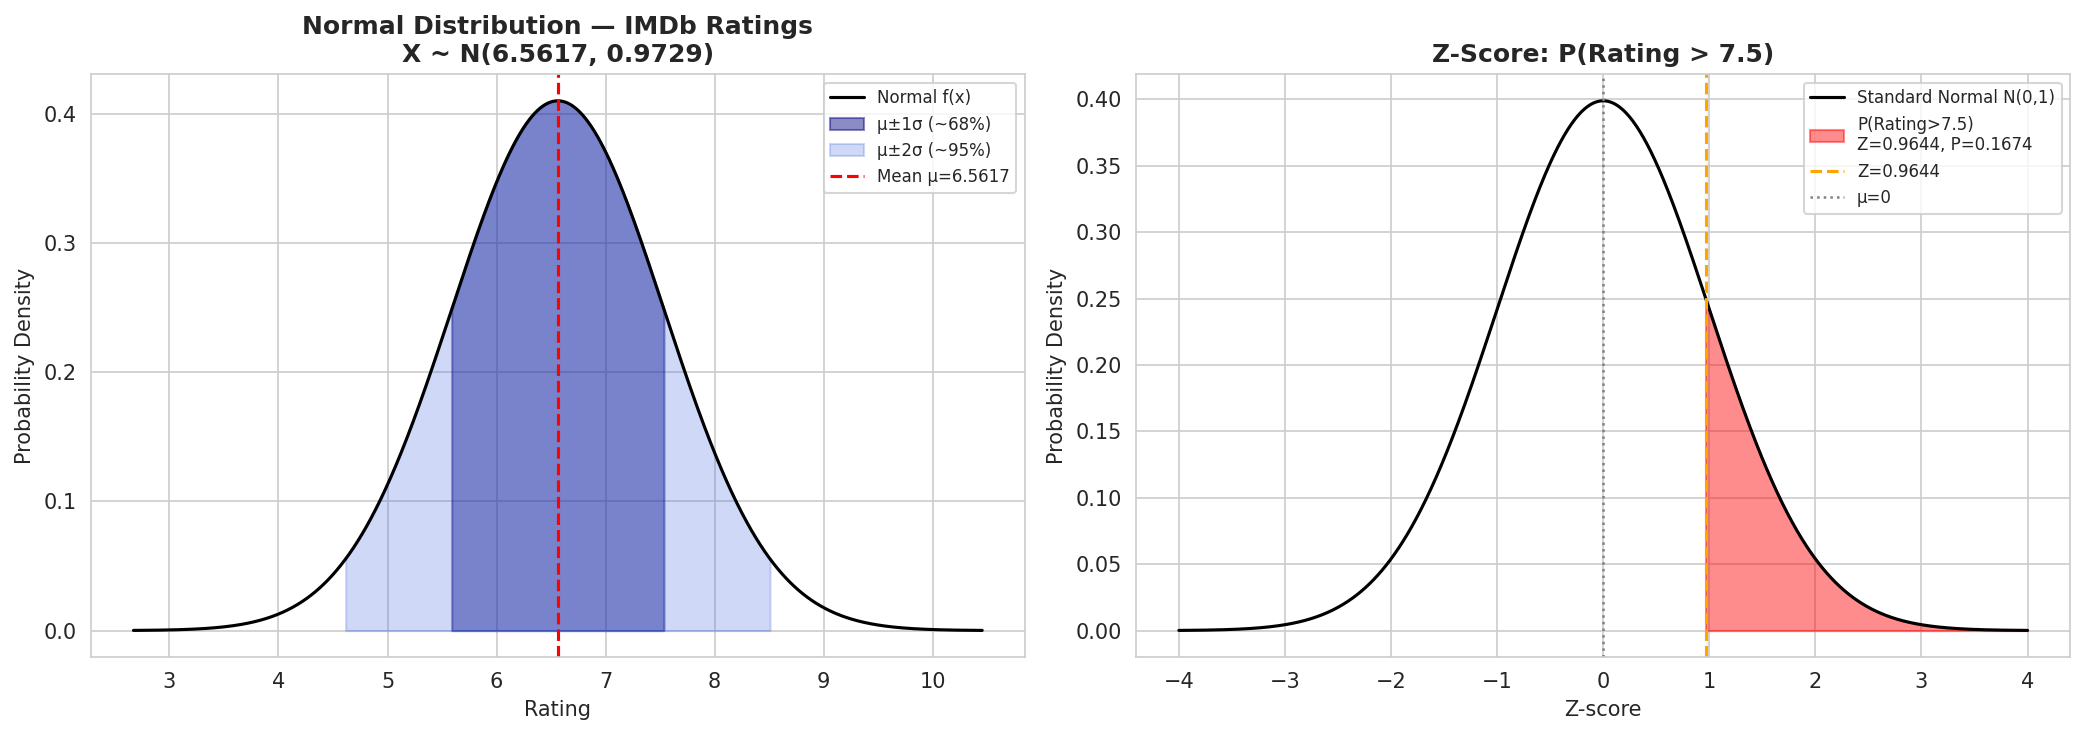

Z = 0.9644
P(Rating > 7.5) = 0.1674 (16.74%)


In [16]:
# ============================================================
# SECTION 4D: Normal Distribution + Z-Score Visualization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = df_clean['Rating'].mean()
sigma = df_clean['Rating'].std()

# Example value
x_val = 7.5
z = (x_val - mu) / sigma
p_above = 1 - norm.cdf(z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Left Plot: Normal Distribution with Empirical Rule
# ------------------------------------------------------------
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

axes[0].plot(x, y, color='black', linewidth=1.5, label='Normal f(x)')

# ±1σ region
x1 = np.linspace(mu-sigma, mu+sigma, 500)
axes[0].fill_between(
    x1,
    norm.pdf(x1, mu, sigma),
    color='navy',
    alpha=0.45,
    label='μ±1σ (~68%)'
)

# ±2σ region
x2 = np.linspace(mu-2*sigma, mu+2*sigma, 500)
axes[0].fill_between(
    x2,
    norm.pdf(x2, mu, sigma),
    color='royalblue',
    alpha=0.25,
    label='μ±2σ (~95%)'
)

axes[0].axvline(
    mu,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean μ={mu:.4f}'
)

axes[0].set_title(
    f'Normal Distribution — IMDb Ratings\nX ~ N({mu:.4f}, {sigma:.4f})',
    fontweight='bold'
)

axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# Right Plot: Z-Score Probability
# ------------------------------------------------------------
z_x = np.linspace(-4, 4, 1000)
z_y = norm.pdf(z_x)

axes[1].plot(
    z_x,
    z_y,
    color='black',
    linewidth=1.5,
    label='Standard Normal N(0,1)'
)

# Shade area to the right of z
z_fill = np.linspace(z, 4, 300)
axes[1].fill_between(
    z_fill,
    norm.pdf(z_fill),
    color='red',
    alpha=0.45,
    label=f'P(Rating>{x_val})\nZ={z:.4f}, P={p_above:.4f}'
)

axes[1].axvline(
    z,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Z={z:.4f}'
)

axes[1].axvline(
    0,
    color='gray',
    linestyle=':',
    linewidth=1.2,
    label='μ=0'
)

axes[1].set_title(
    f'Z-Score: P(Rating > {x_val})',
    fontweight='bold'
)

axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# Save & Show
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig(
    'fig4_normal_distribution_zscore.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print(f'Z = {z:.4f}')
print(f'P(Rating > {x_val}) = {p_above:.4f} ({p_above*100:.2f}%)')

Population mean (mu):          6.5617
Population std (sigma):        0.9729
Sample size (n):               50
Number of simulations:         5000
Theoretical SE:                0.1376
Empirical SE:                  0.1390
Empirical mean:                6.5626


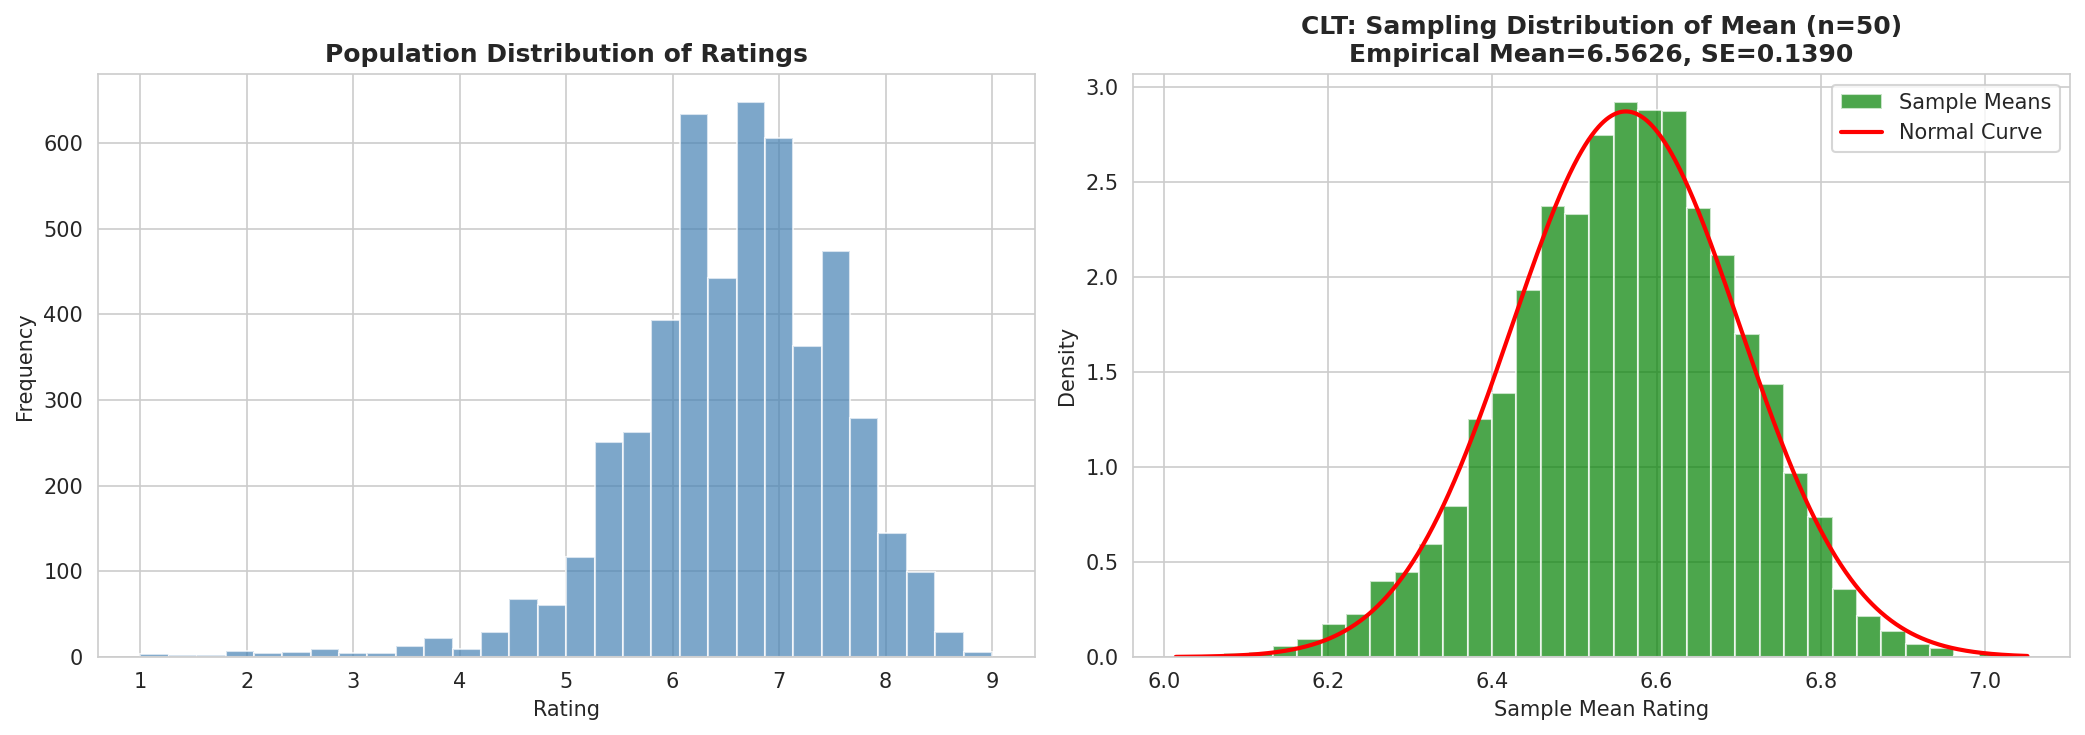

In [18]:
# ============================================================
# SECTION 4E: Central Limit Theorem (CLT) + Visualization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

n_samples = 5000
sample_size = 50

# Monte Carlo simulation
sample_means = [
    df_clean['Rating'].sample(sample_size).mean()
    for _ in range(n_samples)
]

sample_means = np.array(sample_means)

# Statistics
theoretical_se = sigma / np.sqrt(sample_size)
empirical_se = sample_means.std()
empirical_mean = sample_means.mean()

print(f'Population mean (mu):          {mu:.4f}')
print(f'Population std (sigma):        {sigma:.4f}')
print(f'Sample size (n):               {sample_size}')
print(f'Number of simulations:         {n_samples}')
print(f'Theoretical SE:                {theoretical_se:.4f}')
print(f'Empirical SE:                  {empirical_se:.4f}')
print(f'Empirical mean:                {empirical_mean:.4f}')

# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Left: Population Distribution
# ------------------------------------------------------------
axes[0].hist(
    df_clean['Rating'],
    bins=30,
    color='steelblue',
    alpha=0.7,
    edgecolor='white'
)

axes[0].set_title(
    'Population Distribution of Ratings',
    fontweight='bold'
)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# ------------------------------------------------------------
# Right: Sampling Distribution of Sample Means
# ------------------------------------------------------------
axes[1].hist(
    sample_means,
    bins=35,
    density=True,
    color='green',
    alpha=0.7,
    edgecolor='white',
    label='Sample Means'
)

# Normal curve using empirical mean and SE
x = np.linspace(
    sample_means.min(),
    sample_means.max(),
    1000
)

y = norm.pdf(x, empirical_mean, empirical_se)

axes[1].plot(
    x,
    y,
    color='red',
    linewidth=2,
    label='Normal Curve'
)

axes[1].set_title(
    f'CLT: Sampling Distribution of Mean (n={sample_size})\n'
    f'Empirical Mean={empirical_mean:.4f}, SE={empirical_se:.4f}',
    fontweight='bold'
)

axes[1].set_xlabel('Sample Mean Rating')
axes[1].set_ylabel('Density')
axes[1].legend()

# ------------------------------------------------------------
# Save & Show
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig(
    'fig5_clt_sampling_distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [19]:
# ============================================================
# SECTION 5A: Confidence Intervals for Rating
# ============================================================

x_bar = df_clean['Rating'].mean()
s = df_clean['Rating'].std()
n = len(df_clean)
se = s / np.sqrt(n)

print(f'x_bar = {x_bar:.4f}, s = {s:.4f}, n = {n}, SE = {se:.6f}')
print()

for confidence, z_crit in [(0.90, 1.645), (0.95, 1.960), (0.99, 2.576)]:
    lo = x_bar - z_crit * se
    hi = x_bar + z_crit * se
    print(f'{int(confidence*100)}% CI: ({lo:.4f}, {hi:.4f}), Width = {hi-lo:.4f}')


x_bar = 6.5617, s = 0.9729, n = 4999, SE = 0.013760

90% CI: (6.5391, 6.5843), Width = 0.0453
95% CI: (6.5347, 6.5887), Width = 0.0539
99% CI: (6.5263, 6.5972), Width = 0.0709


In [20]:
# ============================================================
# SECTION 5B: Test 1 — One-Sample Z-test (Rating vs 6.5)
# ============================================================

mu0 = 6.5
Z1 = (x_bar - mu0) / se
p1 = 2 * (1 - stats.norm.cdf(abs(Z1)))

print(f'H0: mu_Rating = {mu0}  (Two-tailed)')
print(f'H1: mu_Rating != {mu0}')
print(f'Z-statistic = {Z1:.4f}')
print(f'p-value = {p1:.6f}')
print(f'Decision: {"REJECT H0" if p1 < 0.05 else "FAIL TO REJECT H0"} at alpha=0.05')


H0: mu_Rating = 6.5  (Two-tailed)
H1: mu_Rating != 6.5
Z-statistic = 4.4849
p-value = 0.000007
Decision: REJECT H0 at alpha=0.05


In [27]:
# SECTION 5C: Test 2 — One-Sample Z-test (Duration: High-Rated vs Overall Mean)
# ============================================================

mu0_duration = df_clean['Duration'].mean()          # overall mean as benchmark
high_duration = df_clean[df_clean['HighRated'] == 1]['Duration']

se2 = df_clean['Duration'].std() / np.sqrt(len(high_duration))   # population std / sqrt(n)
Z2  = (high_duration.mean() - mu0_duration) / se2
p2  = 2 * (1 - stats.norm.cdf(abs(Z2)))

print(f'\nH0: mu_Duration(HighRated) = {mu0_duration:.2f}  (Two-tailed)')
print(f'H1: mu_Duration(HighRated) != {mu0_duration:.2f}')
print(f'High-rated Duration mean:  {high_duration.mean():.4f}')
print(f'Overall    Duration mean:  {mu0_duration:.4f}')
print(f'Z-statistic = {Z2:.4f}')
print(f'p-value = {p2:.8f}')
print(f'Decision: {"REJECT H0" if p2 < 0.05 else "FAIL TO REJECT H0"} at alpha=0.05')


H0: mu_Duration(HighRated) = 112.07  (Two-tailed)
H1: mu_Duration(HighRated) != 112.07
High-rated Duration mean:  120.8067
Overall    Duration mean:  112.0650
Z-statistic = 17.7026
p-value = 0.00000000
Decision: REJECT H0 at alpha=0.05


In [22]:
# ============================================================
# SECTION 5D: Test 3 — One-Sample Z-test (Votes: High vs Overall)
# ============================================================

mu_votes = df_clean['Votes'].mean()
high_votes = df_clean[df_clean['HighRated']==1]['Votes']
se3 = df_clean['Votes'].std() / np.sqrt(len(high_votes))
Z3 = (high_votes.mean() - mu_votes) / se3
p3 = 2 * (1 - stats.norm.cdf(abs(Z3)))

print(f'Overall Votes mean:       {mu_votes:.2f}')
print(f'High-rated Votes mean:    {high_votes.mean():.2f}')
print(f'Z-statistic = {Z3:.4f}')
print(f'p-value = {p3:.10f}')
print(f'Decision: {"REJECT H0" if p3 < 0.05 else "FAIL TO REJECT H0"} at alpha=0.05')


Overall Votes mean:       143591.93
High-rated Votes mean:    221764.84
Z-statistic = 16.4354
p-value = 0.0000000000
Decision: REJECT H0 at alpha=0.05


In [23]:
# ============================================================
# SECTION 6A: Pearson Correlation Matrix
# ============================================================

corr_df = df_clean[['Rating','Duration','Votes']].copy()
corr_df['Budget']  = df_clean['Budget'].replace(0, np.nan)
corr_df['Revenue'] = df_clean['Revenue'].replace(0, np.nan)

corr_matrix = corr_df.corr()
print('Pearson Correlation Matrix:')
print(corr_matrix.round(4))



Pearson Correlation Matrix:
          Rating  Duration   Votes  Budget  Revenue
Rating    1.0000    0.3349  0.3433 -0.0008   0.1427
Duration  0.3349    1.0000  0.2355  0.2398   0.2124
Votes     0.3433    0.2355  1.0000  0.4281   0.6147
Budget   -0.0008    0.2398  0.4281  1.0000   0.7231
Revenue   0.1427    0.2124  0.6147  0.7231   1.0000


In [24]:
# ============================================================
# SECTION 6B: Simple Linear Regression (Votes -> Rating)
# ============================================================

x = df_clean['Votes'].values
y = df_clean['Rating'].values

slope, intercept, r, p_val, se_reg = stats.linregress(x, y)
r2 = r**2

print(f'Simple Linear Regression: Votes -> Rating')
print(f'Intercept (beta_0) = {intercept:.6f}')
print(f'Slope     (beta_1) = {slope:.8f}')
print(f'R (Pearson r)      = {r:.4f}')
print(f'R-squared          = {r2:.4f}')
print(f'p-value            = {p_val:.4e}')
print(f'Regression equation: Rating = {intercept:.4f} + {slope:.2e} x Votes')



Simple Linear Regression: Votes -> Rating
Intercept (beta_0) = 6.325716
Slope     (beta_1) = 0.00000164
R (Pearson r)      = 0.3433
R-squared          = 0.1179
p-value            = 2.5455e-138
Regression equation: Rating = 6.3257 + 1.64e-06 x Votes


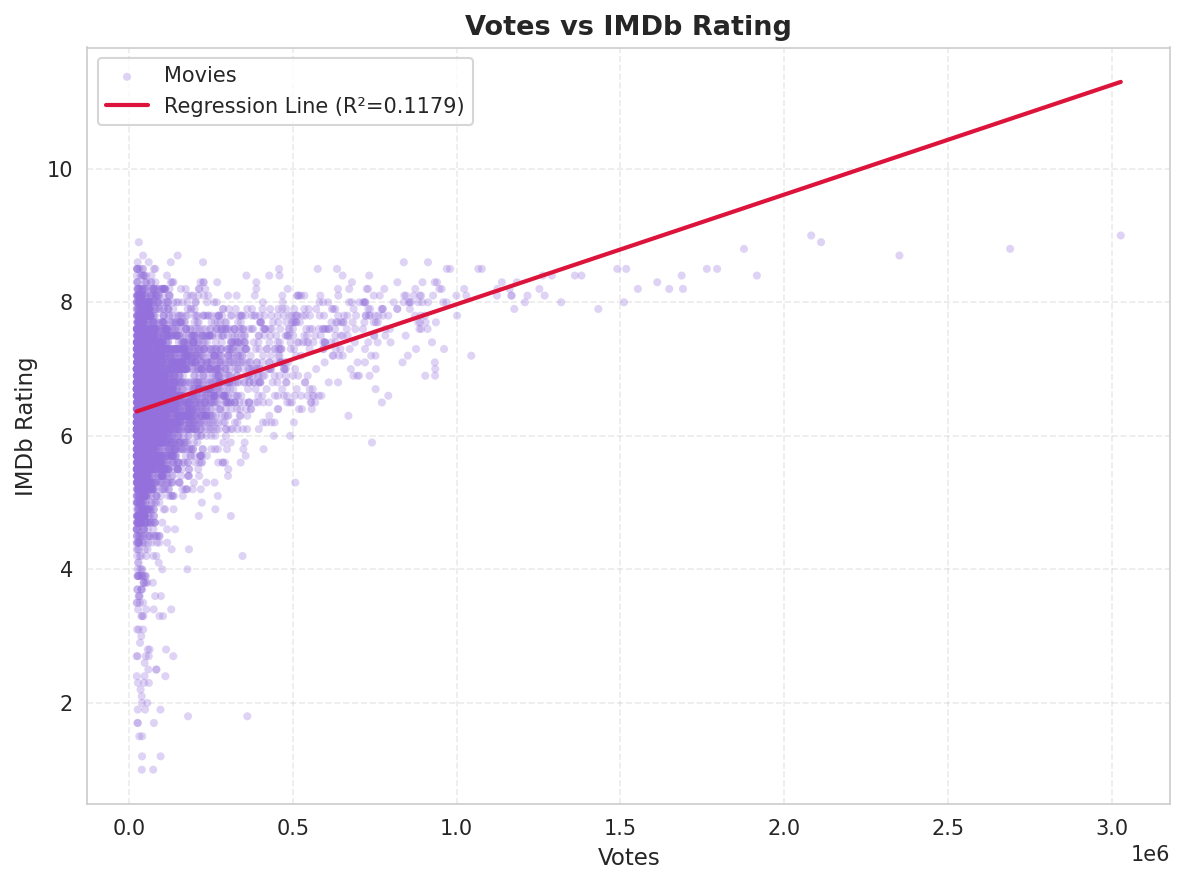

In [34]:
# ============================================================
# SCATTER PLOT: Votes vs Rating WITH REGRESSION LINE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Data
x = df_clean['Votes']
y = df_clean['Rating']

# Linear regression
slope, intercept, r, p_reg, se_reg = stats.linregress(x, y)

# Scatter plot
ax.scatter(
    x, y,
    alpha=0.3,
    color='mediumpurple',
    edgecolors='none',
    s=15,
    label='Movies'
)

# Regression line
ax.plot(
    sorted(x),
    slope * np.array(sorted(x)) + intercept,
    color='crimson',
    linewidth=2,
    label=f'Regression Line (R²={r**2:.4f})'
)

# Titles and labels
ax.set_title('Votes vs IMDb Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Votes', fontsize=11)
ax.set_ylabel('IMDb Rating', fontsize=11)

# Legend and grid
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# SECTION 6C: Multiple Linear Regression (Duration + Votes -> Rating)
# ============================================================

X = np.column_stack([np.ones(len(df_clean)),
                     df_clean['Duration'],
                     df_clean['Votes']])
y = df_clean['Rating'].values

# Solve using ordinary least squares
b, residuals, rank, sv = lstsq(X, y, rcond=None)

y_pred = X @ b
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_multi = 1 - ss_res / ss_tot
n_params = X.shape[1]
r2_adj = 1 - (1 - r2_multi) * (len(y)-1) / (len(y)-n_params)

print(f'Multiple Linear Regression: Duration + Votes -> Rating')
print(f'Intercept  (beta_0) = {b[0]:.4f}')
print(f'Duration    (beta_1) = {b[1]:.6f}')
print(f'Votes      (beta_2) = {b[2]:.10f}')
print(f'R-squared           = {r2_multi:.4f}')
print(f'Adjusted R-squared  = {r2_adj:.4f}')
print()
print(f'Equation: Rating = {b[0]:.4f} + {b[1]:.4f}*Duration + {b[2]:.2e}*Votes')


Multiple Linear Regression: Duration + Votes -> Rating
Intercept  (beta_0) = 4.9795
Duration    (beta_1) = 0.012402
Votes      (beta_2) = 0.0000013403
R-squared           = 0.1862
Adjusted R-squared  = 0.1859

Equation: Rating = 4.9795 + 0.0124*Duration + 1.34e-06*Votes
